### 1. Постановка задачи
**Задача:** Классификация отзывов об образовательном курсе с помощью Hugging Face Transformers:
*   **Класс 0:** негативный
*   **Класс 1:** позитивный

**Дообучение:** использовалась модель DistilBERT

In [1]:
try:
    import inspect
    from typing import Dict
    import numpy as np
    import torch
    import matplotlib.pyplot as plt
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        Trainer,
        TrainingArguments,
        pipeline,
        set_seed as hf_set_seed,
    )
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Для Hugging Face-раздела нужны torch, transformers и accelerate."
        "Установите: python -m pip install torch transformers accelerate"
    ) from exc

SEED = 42
hf_set_seed(SEED)
np.random.seed(SEED)

print("Hugging Face Transformers импортирован")

Hugging Face Transformers импортирован


## 2. Описание и подготовка данных

In [2]:
raw_texts = [
    "The course was clear and practical.",           # POSITIVE (1)
    "The explanation was confusing and too fast.",   # NEGATIVE (0)
    "I like this lesson.",                            # POSITIVE (1)
    "This example is not useful.",                    # NEGATIVE (0)
    "The model works well on my task.",               # POSITIVE (1)
    "The result is bad and unstable.",                # NEGATIVE (0)
    "Amazing content, highly recommend to everyone.", # POSITIVE (1)
    "Waste of time, the instructor was boring.",      # NEGATIVE (0)
    "Very useful tips and structured information.",   # POSITIVE (1)
    "Too expensive for such basic knowledge.",         # NEGATIVE (0)
    "It helped me solve my work problem quickly.",    # POSITIVE (1)
    "Terrible quality, audio is constantly breaking." # NEGATIVE (0)
]
raw_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

model_name = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
encoded = tokenizer(
    raw_texts,
    truncation=True,
    padding=True,
    max_length=64,
    return_tensors="pt",
)

full_dataset = []
for i in range(len(raw_labels)):
    item = {key: value[i] for key, value in encoded.items()}
    item["labels"] = torch.tensor(raw_labels[i], dtype=torch.long)
    full_dataset.append(item)

print(f"Всего подготовлено примеров: {len(full_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Всего подготовлено примеров: 12


## 3. Разделение на train / validation / test.

In [3]:
train_dataset = full_dataset[:8]
valid_dataset = full_dataset[8:10]
test_dataset = full_dataset[10:]

print(f"  - Train dataset: {len(train_dataset)} примеров")
print(f"  - Validation dataset: {len(valid_dataset)} примеров")
print(f"  - Test dataset: {len(test_dataset)} примеров")

example = train_dataset[0]
print("\nСтруктура первого примера в датасете:")
print({k: v.shape if hasattr(v, 'shape') else type(v) for k, v in example.items()})

  - Train dataset: 8 примеров
  - Validation dataset: 2 примеров
  - Test dataset: 2 примеров

Структура первого примера в датасете:
{'input_ids': torch.Size([11]), 'token_type_ids': torch.Size([11]), 'attention_mask': torch.Size([11]), 'labels': torch.Size([])}


## 4. Выбор модели

In [4]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {value: key for key, value in id2label.items()}

pretrained_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

print("Модель успешно инициализирована.")
print("Количество параметров:", sum(p.numel() for p in pretrained_model.parameters()))

with torch.no_grad():
    batch = {key: value.unsqueeze(0) for key, value in example.items() if key != "labels"}
    output = pretrained_model(**batch)

print("Loss до обучения:", float(output.loss) if output.loss is not None else "N/A")
print("Logits до обучения:", output.logits)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель успешно инициализирована.
Количество параметров: 66955010
Loss до обучения: N/A
Logits до обучения: tensor([[-0.0052, -0.0501]])


## 5. Обучение модели

In [10]:
def make_training_args(**kwargs) -> TrainingArguments:
    """Совместимость с новыми и старыми версиями transformers: eval_strategy/evaluation_strategy."""
    parameters = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" not in parameters and "eval_strategy" in kwargs:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    return TrainingArguments(**kwargs)

def compute_accuracy(eval_pred) -> Dict[str, float]:
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": float((predictions == labels).mean())}

RUN_PRETRAINED_FINE_TUNING = True

if RUN_PRETRAINED_FINE_TUNING:
    args = make_training_args(
        output_dir="./hf_text_runs",
        learning_rate=5e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=10,
        weight_decay=0.01,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        report_to="none",
        disable_tqdm=True,
    )

    text_trainer = Trainer(
        model=pretrained_model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        compute_metrics=compute_accuracy,
    )

    text_trainer.train()

{'loss': '0.603', 'grad_norm': '2.526', 'learning_rate': '4.75e-05', 'epoch': '1'}
{'eval_loss': '0.672', 'eval_accuracy': '1', 'eval_runtime': '0.1015', 'eval_samples_per_second': '19.71', 'eval_steps_per_second': '9.854', 'epoch': '1'}
{'loss': '0.5368', 'grad_norm': '4.781', 'learning_rate': '4.25e-05', 'epoch': '2'}
{'eval_loss': '0.6586', 'eval_accuracy': '1', 'eval_runtime': '0.0935', 'eval_samples_per_second': '21.39', 'eval_steps_per_second': '10.69', 'epoch': '2'}
{'loss': '0.4204', 'grad_norm': '3.298', 'learning_rate': '3.75e-05', 'epoch': '3'}
{'eval_loss': '0.6299', 'eval_accuracy': '1', 'eval_runtime': '0.066', 'eval_samples_per_second': '30.3', 'eval_steps_per_second': '15.15', 'epoch': '3'}
{'loss': '0.3068', 'grad_norm': '3.241', 'learning_rate': '3.25e-05', 'epoch': '4'}
{'eval_loss': '0.5983', 'eval_accuracy': '1', 'eval_runtime': '0.0624', 'eval_samples_per_second': '32.04', 'eval_steps_per_second': '16.02', 'epoch': '4'}
{'loss': '0.2422', 'grad_norm': '2.336', 'le

## 6. Графики loss / метрик

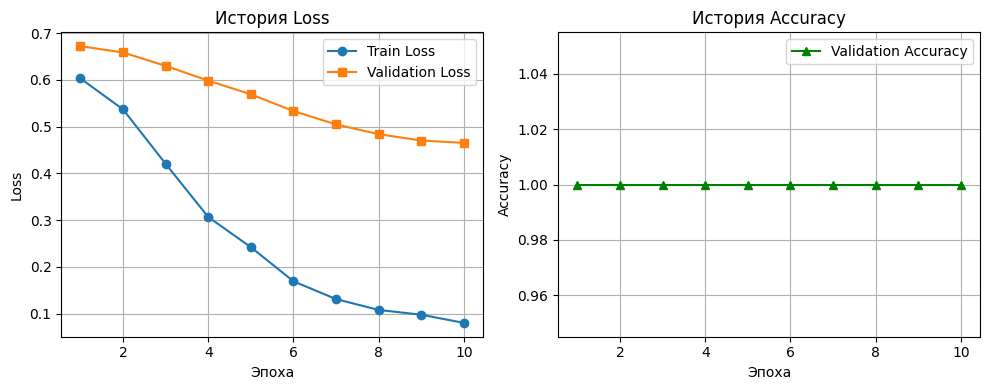

In [11]:
if RUN_PRETRAINED_FINE_TUNING:
    epochs_list = []
    train_losses = []
    eval_losses = []
    eval_accuracies = []

    # Сбор данных из логов
    for log in text_trainer.state.log_history:
        if "loss" in log and "epoch" in log:
            train_losses.append(log["loss"])
            epochs_list.append(log["epoch"])
        if "eval_loss" in log:
            eval_losses.append(log["eval_loss"])
        if "eval_accuracy" in log:
            eval_accuracies.append(log["eval_accuracy"])

    # Отрисовка графиков
    plt.figure(figsize=(10, 4))

    # График потерь
    plt.subplot(1, 2, 1)
    plt.plot(epochs_list, train_losses, label='Train Loss', marker='o')
    if len(eval_losses) == len(train_losses):
        plt.plot(epochs_list, eval_losses, label='Validation Loss', marker='s')
    plt.title('История Loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # График метрики
    plt.subplot(1, 2, 2)
    if eval_accuracies:
        plt.plot(epochs_list, eval_accuracies, label='Validation Accuracy', color='g', marker='^')
    plt.title('История Accuracy')
    plt.xlabel('Эпоха')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## 7. Оценка на test set

In [12]:
if RUN_PRETRAINED_FINE_TUNING:
    print("--- Финальная оценка на test set ---")
    test_metrics = text_trainer.evaluate(eval_dataset=test_dataset)

    print(f"Тестовый Loss: {test_metrics['eval_loss']:.4f}")
    print(f"Тестовая Точность (Accuracy): {test_metrics['eval_accuracy']:.4f}")

--- Финальная оценка на test set ---
{'eval_loss': '0.5429', 'eval_accuracy': '0.5', 'eval_runtime': '0.0723', 'eval_samples_per_second': '27.66', 'eval_steps_per_second': '13.83', 'epoch': '10'}
Тестовый Loss: 0.5429
Тестовая Точность (Accuracy): 0.5000


## 8. Применение модели

In [13]:
RUN_PIPELINE_INFERENCE = True

if RUN_PIPELINE_INFERENCE:
    if RUN_PRETRAINED_FINE_TUNING:
        classifier = pipeline(
            "sentiment-analysis",
            model=pretrained_model,
            tokenizer=tokenizer,
            device=0 if torch.cuda.is_available() else -1
        )
    else:
        classifier = pipeline(
            "sentiment-analysis",
            model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
        )

    test_phrase = "This lesson gives practical building blocks."
    print(f"\nТестовая фраза: \"{test_phrase}\"")
    print("Результат классификации:", classifier(test_phrase))


Тестовая фраза: "This lesson gives practical building blocks."
Результат классификации: [{'label': 'POSITIVE', 'score': 0.7389004230499268}]
